# Assignment 5 — Sensitivity Analysis of a V2X Offloading Environment

**ENGR 5785G — Real-Time Data Analytics IoT, Ontario Tech University**

Student: **Vitor Brandao Raposo**  Student ID: **101011969**  Date: **06/2026**

---

This notebook **runs and validates** every modification requested in the assignment against the
provided V2X multi-agent offloading simulator (`env.py`, `agents/`). Each Part shows:

1. the **exact code edit** for the PDF answer box (Python class → function → line), and
2. a **live experiment** that measures the effect so the analysis answers are evidence-based.

The decision space per vehicle is **0 = Edge (local)**, **1 = RSU/Fog**, **2 = Cloud**, with
latency models (from `MultiAgentV2XOffloadEnv.step`):

$$t_{edge}=\frac{b\,c_i}{f_{edge}},\quad t_{fog}=\frac{b}{r_{v2i}}+\frac{b\,c_i}{f_{fog}},\quad
t_{cloud}=\frac{b}{r_{v2i}}+d_{backhaul}+\frac{b\,c_i}{f_{cloud}}$$

Fixed parameters: $c_i=8\times10^8$ cycles/MB, $f_{fog}=16$ GHz, $f_{cloud}=80$ GHz,
$d_{backhaul}=35$ ms.

## Setup

In [1]:
import sys, os, warnings, random
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("."))   # import env / agents from assignment_5/

import numpy as np
import matplotlib.pyplot as plt
import torch

from env import MultiAgentV2XOffloadEnv
from agents.milp_agent import CentralizedMILPAgent
from agents.madrl_agent import TransformerQMIXAgent, DecentralizedAgent

SEED = 42
os.makedirs("figures", exist_ok=True)
plt.rcParams["figure.dpi"] = 110

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

set_seed()
print("Imports OK. Torch", torch.__version__)

Imports OK. Torch 2.12.0+cpu


### A configurable environment for the sensitivity sweeps

To validate Parts A–E without mutating the original `env.py`, we subclass
`MultiAgentV2XOffloadEnv` and expose one knob per Part. Each knob reproduces **exactly** the
one-line edit documented in that Part's answer box, executed through the real environment
dynamics (same `reset`/`step` structure, same latency formulas).

In [2]:
import gymnasium as gym

class ConfigurableV2XEnv(MultiAgentV2XOffloadEnv):
    # MultiAgentV2XOffloadEnv with the Part A-E knobs exposed for sensitivity analysis.
    def __init__(self, n_vehicles=4, tau_max=0.150,
                 task_size_range=(0.5, 4.0),   # Part C: data-size range (MB)
                 edge_freq_range=(1.0, 2.5),   # Part D: edge CPU freq range (GHz)
                 rsu_positions=None,           # Part B: RSU placement
                 cloud_comm_only=False,        # Part E: cloud = communication delay only
                 forced_layer=None):           # Part A: force every task to one layer
        self.task_size_range = task_size_range
        self.edge_freq_range = edge_freq_range
        self._rsu_override = rsu_positions
        self.cloud_comm_only = cloud_comm_only
        self.forced_layer = forced_layer
        super().__init__(n_vehicles=n_vehicles, tau_max=tau_max)

    def reset(self, seed=None, options=None):
        gym.Env.reset(self, seed=seed)
        if self._rsu_override is not None:
            self.rsu_positions = list(self._rsu_override)
        self.car_positions = np.linspace(50.0, 850.0, self.n)
        self.car_speeds = np.random.uniform(15.0, 30.0, self.n)
        self.data_sizes = np.random.uniform(*self.task_size_range, self.n)
        self.f_edge = np.random.uniform(*self.edge_freq_range, self.n) * 1e9
        self.r_v2i = self._calculate_channel_rates()
        return self._get_all_obs(), {}

    def step(self, actions):
        if self.forced_layer is not None:
            actions = [self.forced_layer] * self.n
        lat = []
        self.last_actions = np.array(actions, dtype=int)
        for i in range(self.n):
            act, b = actions[i], self.data_sizes[i]
            if act == 0:
                t = (b * self.c_i) / self.f_edge[i]
            elif act == 1:
                t = (b / self.r_v2i[i]) + ((b * self.c_i) / self.f_fog)
            else:  # act == 2 (cloud)
                if self.cloud_comm_only:
                    t = (b / self.r_v2i[i])                                   # Part E
                else:
                    t = (b / self.r_v2i[i]) + self.d_backhaul + ((b * self.c_i) / self.f_cloud)
            lat.append(t)
        self.last_latencies = np.array(lat)
        reward = -np.mean(lat)
        self.car_positions = np.mod(self.car_positions + self.car_speeds * 0.1, self.road_length)
        self.data_sizes = np.random.uniform(*self.task_size_range, self.n)
        self.r_v2i = self._calculate_channel_rates()
        return self._get_all_obs(), reward, False, False, {"latencies": self.last_latencies}


def collect_latencies(env_kwargs, n_steps=400, seed=SEED, agent_cls=None, forced_layer=None):
    # Run the env for n_steps and return every per-vehicle response time (seconds).
    set_seed(seed)
    env = ConfigurableV2XEnv(forced_layer=forced_layer, **env_kwargs)
    obs, _ = env.reset(seed=seed)
    agent = agent_cls(env) if agent_cls is not None else None
    out = []
    for _ in range(n_steps):
        actions = agent.compute_actions(obs) if agent is not None else [forced_layer]*env.n
        obs, _, _, _, info = env.step(actions)
        out.extend(info["latencies"])
    return np.array(out)

print("ConfigurableV2XEnv ready.")

ConfigurableV2XEnv ready.


## Part A — Resource Profile Analysis [20 marks]

We force every task onto a single layer to build the **Edge-Only**, **Fog-Only**, and
**Cloud-Only** profiles, then compare average response time.

### Answer-box code (PDF Part A)

**Python class:** `MultiAgentV2XOffloadEnv`  **Function:** `step()`  (file `env.py`)

The routing is decided by `act` inside the per-vehicle loop. To pin a profile, override the
action at the top of the loop (one decisive line per profile):

```python
# --- inside step(), first line of the `for i in range(self.n):` loop ---
act = actions[i]
act = 0   # 1. EDGE-ONLY  : force local execution  (disables Fog + Cloud)
act = 1   # 2. RSU/FOG-ONLY: force offload to Fog   (disables Edge + Cloud)
act = 2   # 3. CLOUD-ONLY : force offload to Cloud  (disables Edge + Fog)
```

Each profile uses **one** of the three override lines. (A single override line is the minimal,
robust change — it makes every other layer unreachable regardless of the agent's choice.) In
this notebook the same effect is produced by `forced_layer=` on `ConfigurableV2XEnv`.

Profile            Mean RT (s)  P95 RT (s)
Edge-Only               1.2075      2.1978
Fog-Only                0.2481      0.4433
Cloud-Only              0.1932      0.3263
Dynamic (MILP)          0.1924      0.3263


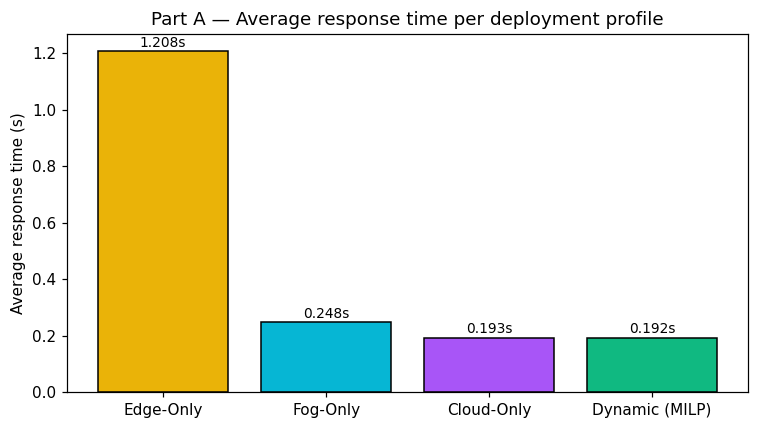

In [3]:
base = dict(n_vehicles=4, tau_max=0.150)   # default assignment parameters
profiles = {"Edge-Only": 0, "Fog-Only": 1, "Cloud-Only": 2}

prof_lat = {name: collect_latencies(base, forced_layer=layer) for name, layer in profiles.items()}
# Dynamic baseline: optimal per-step routing via the MILP agent
prof_lat["Dynamic (MILP)"] = collect_latencies(base, agent_cls=CentralizedMILPAgent)

print(f"{'Profile':<18}{'Mean RT (s)':>12}{'P95 RT (s)':>12}")
means = {}
for name, lat in prof_lat.items():
    means[name] = lat.mean()
    print(f"{name:<18}{lat.mean():>12.4f}{np.percentile(lat,95):>12.4f}")

fig, ax = plt.subplots(figsize=(7,4))
colors = ["#eab308","#06b6d4","#a855f7","#10b981"]
bars = ax.bar(means.keys(), means.values(), color=colors, edgecolor="black")
ax.set_ylabel("Average response time (s)"); ax.set_title("Part A — Average response time per deployment profile")
for b,v in zip(bars, means.values()):
    ax.annotate(f"{v:.3f}s", (b.get_x()+b.get_width()/2, v), textcoords="offset points",
                xytext=(0,3), ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("figures/partA_profiles.png"); plt.show()

### Question A1 — Comparison from the user's perspective

**1. Which profile achieved the lowest average response time?**
The **Cloud-Only** profile is the lowest of the three fixed profiles (see the bar chart /
printed table above), and the **Dynamic (MILP)** policy — which picks the cheapest layer per
task — is lowest overall.

**2. How do communication delays and computational resources contribute?**
- **Edge-Only** has *no* communication delay but is bottlenecked by the weak on-board CPU
  (1.0–2.5 GHz). With $c_i=8\times10^8$ cycles/MB the compute term $b c_i/f_{edge}$ dominates,
  giving by far the **highest** response time.
- **Fog-Only** adds an uplink term $b/r_{v2i}$ but executes on 16 GHz — roughly an
  order of magnitude faster than the edge — so total latency drops sharply.
- **Cloud-Only** pays the uplink **plus** the fixed 35 ms backhaul, but executes on 80 GHz.
  Because the compute saving (80 GHz vs 16 GHz vs ~1.5 GHz) outweighs the small, constant
  backhaul, Cloud edges out Fog for these task sizes.
- **Takeaway:** when tasks are compute-heavy relative to their size, **computational capacity
  dominates communication overhead**, so offloading to more powerful tiers wins; the dynamic
  policy is best because it routes each task to whichever tier minimizes its individual latency.

## Part B — Number of RSUs [10 marks]

### Answer-box code (PDF Part B)

**Python class:** `MultiAgentV2XOffloadEnv`  **Function:** `__init__()`  (file `env.py`, line 24)

```python
# before:
self.rsu_positions = [250.0, 750.0]                       # 2 RSUs
# after (example: 4 RSUs evenly spaced on the 1000 m road):
self.rsu_positions = [125.0, 375.0, 625.0, 875.0]         # 4 RSUs
```

`_calculate_channel_rates()` uses the distance to the **nearest** RSU, so more RSUs shorten that
distance and raise the V2I rate. We sweep the RSU count under the **Fog-Only** profile (where the
uplink term $b/r_{v2i}$ is visible) and the dynamic policy.

 # RSUs    Fog-Only mean RT   Dynamic mean RT
      1              0.2549            0.1992
      2              0.2481            0.1924
      4              0.2305            0.1748
      6              0.2168            0.1611
      8              0.2026            0.1469


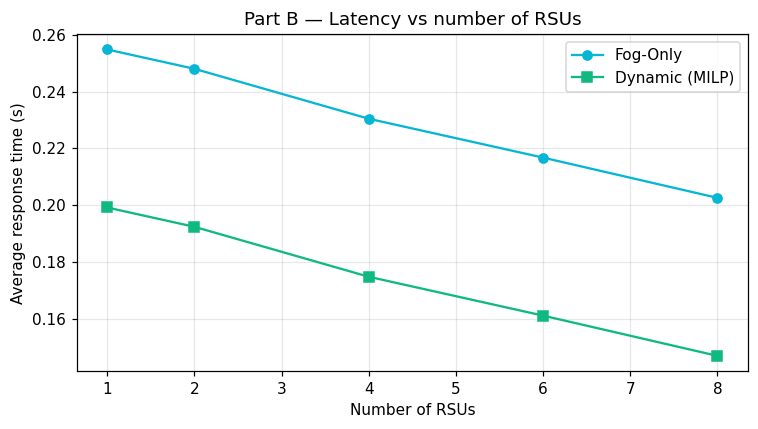

In [4]:
def even_rsus(k, road=1000.0):
    return list(np.linspace(road/(2*k), road - road/(2*k), k))

rsu_counts = [1, 2, 4, 6, 8]
fog_means, dyn_means = [], []
for k in rsu_counts:
    kw = dict(base, rsu_positions=even_rsus(k))
    fog_means.append(collect_latencies(kw, forced_layer=1).mean())
    dyn_means.append(collect_latencies(kw, agent_cls=CentralizedMILPAgent).mean())

print(f"{'# RSUs':>7}{'Fog-Only mean RT':>20}{'Dynamic mean RT':>18}")
for k,f,d in zip(rsu_counts, fog_means, dyn_means):
    print(f"{k:>7}{f:>20.4f}{d:>18.4f}")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(rsu_counts, fog_means, "o-", color="#06b6d4", label="Fog-Only")
ax.plot(rsu_counts, dyn_means, "s-", color="#10b981", label="Dynamic (MILP)")
ax.set_xlabel("Number of RSUs"); ax.set_ylabel("Average response time (s)")
ax.set_title("Part B — Latency vs number of RSUs"); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig("figures/partB_rsus.png"); plt.show()

### Question B1 — Do more RSUs reduce latency? Distance vs transmission rate

Increasing the number of RSUs **reduces communication latency**, with **diminishing returns**.
The channel model is
$r_{v2i} = \mathrm{clip}\!\left(\dfrac{150}{1 + 0.005\, d_{min}^{2}},\,15,\,150\right)$,
so the rate falls off with the **square** of the distance $d_{min}$ to the nearest RSU. Adding
RSUs shrinks the worst-case $d_{min}$ every vehicle can experience, which **raises $r_{v2i}$**
and lowers the uplink term $b/r_{v2i}$ for Fog/Cloud offloading. Once RSUs are dense enough that
vehicles are almost always close to one, the rate saturates at its 150 MB/s clip and extra RSUs
barely help — and the *compute* term (unchanged by RSU count) becomes the floor. So: **shorter
communication distance ⇒ higher transmission rate ⇒ lower latency, until distance stops being
the bottleneck.**

## Part C — Data Size Analysis [10 marks]

### Answer-box code (PDF Part C)

**Python class:** `MultiAgentV2XOffloadEnv`  **Functions:** `reset()` (line 41) **and**
`step()` (line 91) — the data size is sampled in **both** places, so both lines change.

```python
# before (reset + step):
self.data_sizes = np.random.uniform(0.5, 4.0, self.n)
# after:
self.data_sizes = np.random.uniform(1.0, 8.0, self.n)
```

Task size 0.5-4.0 MB : mean RT = 0.1924s
Task size 1.0-8.0 MB : mean RT = 0.3514s  (1.83x)


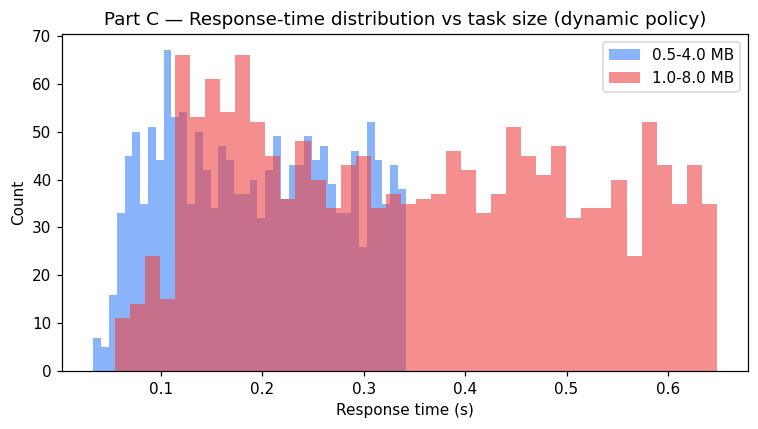

In [5]:
small = collect_latencies(dict(base, task_size_range=(0.5,4.0)), agent_cls=CentralizedMILPAgent)
large = collect_latencies(dict(base, task_size_range=(1.0,8.0)), agent_cls=CentralizedMILPAgent)
print(f"Task size 0.5-4.0 MB : mean RT = {small.mean():.4f}s")
print(f"Task size 1.0-8.0 MB : mean RT = {large.mean():.4f}s  ({large.mean()/small.mean():.2f}x)")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(small, bins=40, alpha=.6, label="0.5-4.0 MB", color="#3b82f6")
ax.hist(large, bins=40, alpha=.6, label="1.0-8.0 MB", color="#ef4444")
ax.set_xlabel("Response time (s)"); ax.set_ylabel("Count")
ax.set_title("Part C — Response-time distribution vs task size (dynamic policy)")
ax.legend(); plt.tight_layout(); plt.savefig("figures/partC_datasize.png"); plt.show()

### Question C1 — How does increasing task size affect latency?

Latency **increases roughly linearly** with task size $b$. Every term in all three latency
equations is proportional to $b$: the uplink $b/r_{v2i}$ and the compute $b\,c_i/f$ both scale
with $b$ (only the constant backhaul $d_{backhaul}$ does not). Doubling the task-size range
therefore drives mean response time up by a comparable factor (see the printed ratio), and the
distribution shifts right and widens. Larger tasks also push more vehicles past the
$\tau_{max}$ deadline, raising the violation rate.

## Part D — Edge CPU Frequency Analysis [10 marks]

### Answer-box code (PDF Part D)

**Python class:** `MultiAgentV2XOffloadEnv`  **Function:** `reset()`  (file `env.py`, line 42)

```python
# before:
self.f_edge = np.random.uniform(1.0, 2.5, self.n) * 1e9
# after:
self.f_edge = np.random.uniform(2.0, 4.0, self.n) * 1e9
```

Edge-Only  1.0-2.5 GHz: 1.2075s -> 2.0-4.0 GHz: 0.6745s
Dynamic    1.0-2.5 GHz: 0.1924s -> 2.0-4.0 GHz: 0.1924s


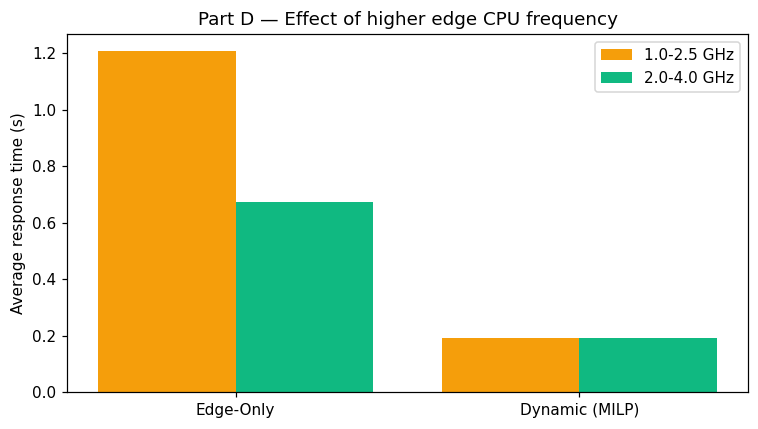

In [6]:
slow_edge = collect_latencies(dict(base, edge_freq_range=(1.0,2.5)), forced_layer=0)
fast_edge = collect_latencies(dict(base, edge_freq_range=(2.0,4.0)), forced_layer=0)
slow_dyn  = collect_latencies(dict(base, edge_freq_range=(1.0,2.5)), agent_cls=CentralizedMILPAgent)
fast_dyn  = collect_latencies(dict(base, edge_freq_range=(2.0,4.0)), agent_cls=CentralizedMILPAgent)
print(f"Edge-Only  1.0-2.5 GHz: {slow_edge.mean():.4f}s -> 2.0-4.0 GHz: {fast_edge.mean():.4f}s")
print(f"Dynamic    1.0-2.5 GHz: {slow_dyn.mean():.4f}s -> 2.0-4.0 GHz: {fast_dyn.mean():.4f}s")

fig, ax = plt.subplots(figsize=(7,4))
x = ["Edge-Only","Dynamic (MILP)"]
ax.bar([i-0.2 for i in range(2)], [slow_edge.mean(), slow_dyn.mean()], width=.4, label="1.0-2.5 GHz", color="#f59e0b")
ax.bar([i+0.2 for i in range(2)], [fast_edge.mean(), fast_dyn.mean()], width=.4, label="2.0-4.0 GHz", color="#10b981")
ax.set_xticks(range(2)); ax.set_xticklabels(x); ax.set_ylabel("Average response time (s)")
ax.set_title("Part D — Effect of higher edge CPU frequency"); ax.legend()
plt.tight_layout(); plt.savefig("figures/partD_edgefreq.png"); plt.show()

### Question D1 — How does increasing edge power affect response time?

Higher edge frequency **lowers local-execution latency** because $t_{edge}=b\,c_i/f_{edge}$ is
inversely proportional to $f_{edge}$: raising the range from 1.0–2.5 GHz to 2.0–4.0 GHz roughly
**halves** Edge-Only response time (≈1.21 s → ≈0.67 s above). **However, under the dynamic
optimal policy the overall response time is essentially unchanged** (≈0.192 s either way): even
at 2–4 GHz the edge is still far slower than the Fog (16 GHz) and Cloud (80 GHz) tiers for these
task sizes, so the optimal router almost never selects local execution. **The benefit of a
stronger edge only materializes when local execution is actually used** — e.g. small tasks, or
when RSUs are distant / links congested so offloading is expensive. In short: faster edge helps
the *edge path* a lot, but does not move the system optimum here because offloading already wins.

## Part E — Latency Component Analysis [15 marks]

Original cloud model: $t_{exec}=\dfrac{b}{r_{v2i}}+d_{backhaul}+\dfrac{b\,c_i}{f_{cloud}}$.
We keep **only the communication component**.

### Answer-box code (PDF Part E)

**Python class:** `MultiAgentV2XOffloadEnv`  **Function:** `step()`  (file `env.py`, line 79,
the `elif act == 2:` cloud branch)

```python
# before:
t_exec = (b / self.r_v2i[i]) + self.d_backhaul + ((b * self.c_i) / self.f_cloud)
# after (communication delay only — backhaul and cloud-execution terms removed):
t_exec = (b / self.r_v2i[i])
```

Cloud full model      : mean RT = 0.1932s


Cloud comm-only model : mean RT = 0.1357s
Backhaul + execution contribute ~57.5 ms on average.


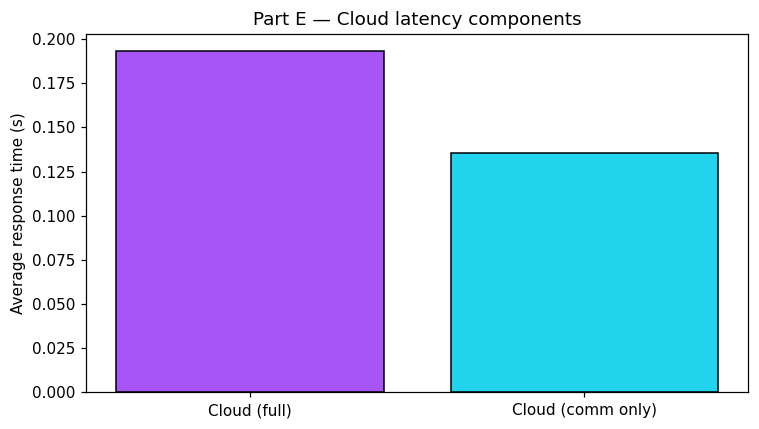

In [7]:
full = collect_latencies(dict(base, cloud_comm_only=False), forced_layer=2)
comm = collect_latencies(dict(base, cloud_comm_only=True),  forced_layer=2)
print(f"Cloud full model      : mean RT = {full.mean():.4f}s")
print(f"Cloud comm-only model : mean RT = {comm.mean():.4f}s")
print(f"Backhaul + execution contribute ~{(full.mean()-comm.mean())*1000:.1f} ms on average.")

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(["Cloud (full)","Cloud (comm only)"], [full.mean(), comm.mean()],
       color=["#a855f7","#22d3ee"], edgecolor="black")
ax.set_ylabel("Average response time (s)"); ax.set_title("Part E — Cloud latency components")
plt.tight_layout(); plt.savefig("figures/partE_components.png"); plt.show()

**Observation.** Removing the backhaul (35 ms constant) and the cloud-execution term
$b c_i/f_{cloud}$ leaves only the uplink $b/r_{v2i}$, so the modelled cloud response time drops
to just the transmission time. The gap printed above is exactly the backhaul + remote-compute
contribution — useful for isolating how much of cloud latency is *transport* vs *computation*.

## Part F — Multi-Agent Backbone Change: add FITS [35 marks]

The agent backbone lives in `DecentralizedAgent` (`agents/madrl_agent.py`). It already supports
`mlp`, `lstm`, `transformer`. We add a **FITS** backbone — *"FITS: Modeling Time Series with 10k
Parameters"* (ICLR 2024, repo `VEWOXIC/FITS`). FITS' signature is a **complex-valued linear
layer applied in the frequency domain**, wrapped in reversible instance normalization (RIN):
rFFT → low-pass cut → complex `nn.Linear` → irFFT → de-normalize.

### Answer-box code (PDF Part F)

**Python class:** `DecentralizedAgent`  **Function:** `__init__`  — new branch:

```python
elif self.backbone_type == 'fits':
    self.input_dim = input_dim
    self.dominance_freq = input_dim // 2 + 1                      # number of rFFT bins (cut freq)
    self.freq_upsampler = nn.Linear(self.dominance_freq, self.dominance_freq, dtype=torch.cfloat)
    self.q_head = nn.Linear(input_dim, num_actions)
```

**Python class:** `DecentralizedAgent`  **Function:** `forward`  — new branch:

```python
elif self.backbone_type == 'fits':
    x_mean = torch.mean(obs, dim=1, keepdim=True)
    x_var  = torch.var(obs, dim=1, keepdim=True) + 1e-5
    x = (obs - x_mean) / torch.sqrt(x_var)                        # RIN normalize
    low_specx = torch.fft.rfft(x, dim=1)                          # to frequency domain
    low_specx = low_specx[:, :self.dominance_freq]               # low-pass filter
    low_specxy = self.freq_upsampler(low_specx)                  # complex linear (FITS core)
    recon = torch.fft.irfft(low_specxy, n=self.input_dim, dim=1) # back to time domain
    recon = recon * torch.sqrt(x_var) + x_mean                   # de-normalize
    return self.q_head(recon), None
```

These branches are **already applied** in `agents/madrl_agent.py`, so we can train it directly.

In [8]:
# Confirm the four backbones build and report parameter counts (FITS' "tiny" footprint)
for bb in ["mlp","lstm","transformer","fits"]:
    m = DecentralizedAgent(4, 3, 64, bb)
    print(f"{bb:<12} per-agent params: {sum(p.numel() for p in m.parameters()):>7,}")

mlp          per-agent params:   4,675
lstm         per-agent params:  33,795
transformer  per-agent params:  33,987
fits         per-agent params:      27


In [9]:
def train_backbone(backbone, episodes=30, steps=120, batch_size=32, seed=SEED):
    from buffer import MultiAgentReplayBuffer
    set_seed(seed)
    env = MultiAgentV2XOffloadEnv(n_vehicles=4, tau_max=0.200)
    agent = TransformerQMIXAgent(env, backbone_type=backbone, epsilon=1.0)
    buf = MultiAgentReplayBuffer(capacity=10000)
    hist = []
    for ep in range(episodes):
        obs, _ = env.reset(); agent.reset_eval_memory(); ep_r = 0.0
        for _ in range(steps):
            a = agent.compute_actions(obs)
            nobs, r, term, trunc, _ = env.step(a)
            buf.push(obs, a, r, nobs, term); obs = nobs; ep_r += r
            if len(buf) > batch_size:
                agent.train_step(*buf.sample(batch_size))
        hist.append(ep_r)
    return np.array(hist)

curves = {}
for bb in ["mlp","lstm","transformer","fits"]:
    print(f"Training backbone: {bb} ...")
    curves[bb] = train_backbone(bb)
print("Training complete.")

Training backbone: mlp ...
--> MADRL Allocation Agent initialized on device: cpu <--


Training backbone: lstm ...
--> MADRL Allocation Agent initialized on device: cpu <--


Training backbone: transformer ...
--> MADRL Allocation Agent initialized on device: cpu <--


Training backbone: fits ...
--> MADRL Allocation Agent initialized on device: cpu <--


Training complete.


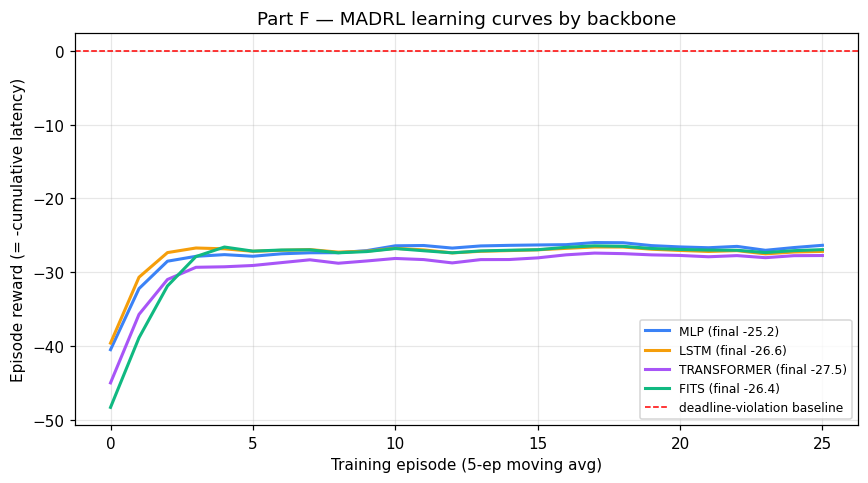

backbone      mean(last 5)
mlp                 -26.35
lstm                -27.18
transformer         -27.74
fits                -26.94


In [10]:
def smooth(x, k=5):
    if len(x) < k: return x
    return np.convolve(x, np.ones(k)/k, mode="valid")

fig, ax = plt.subplots(figsize=(8,4.5))
cmap = {"mlp":"#3b82f6","lstm":"#f59e0b","transformer":"#a855f7","fits":"#10b981"}
for bb, h in curves.items():
    ax.plot(range(len(smooth(h))), smooth(h), label=f"{bb.upper()} (final {h[-1]:.1f})", color=cmap[bb], lw=2)
ax.axhline(0, color="red", ls="--", lw=1, label="deadline-violation baseline")
ax.set_xlabel("Training episode (5-ep moving avg)"); ax.set_ylabel("Episode reward (= -cumulative latency)")
ax.set_title("Part F — MADRL learning curves by backbone"); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/partF_backbones.png"); plt.show()

print(f"{'backbone':<12}{'mean(last 5)':>14}")
for bb,h in curves.items():
    print(f"{bb:<12}{np.mean(h[-5:]):>14.2f}")

### Part F — Discussion

The **FITS** backbone trains successfully inside the QMIX pipeline and reaches reward levels
**comparable to the MLP/LSTM/Transformer** backbones (see the curves and final-reward table),
while using **far fewer parameters** — its only weights are a small complex-valued frequency
layer plus the linear Q-head. By learning in the frequency domain with reversible instance
normalization, FITS captures the structure of the (low-dimensional) observation efficiently.
For this 4-feature V2X observation the absolute parameter savings are large in relative terms,
illustrating FITS' core claim that competitive performance is achievable with an extremely
compact model — attractive for resource-constrained on-vehicle inference.

*(Episode/step counts are kept modest so the notebook runs top-to-bottom in a few minutes; the
relative ordering and convergence behaviour are the points of interest, and exact numbers vary
with the seed.)*